In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset('titanic')

In [2]:
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

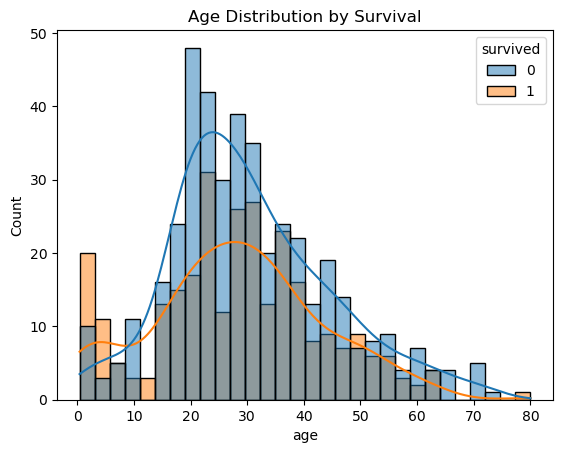

In [4]:
sns.histplot(data=df, x='age', hue='survived', bins=30, kde=True)
plt.title('Age Distribution by Survival')
plt.show()

<Axes: xlabel='age', ylabel='Count'>

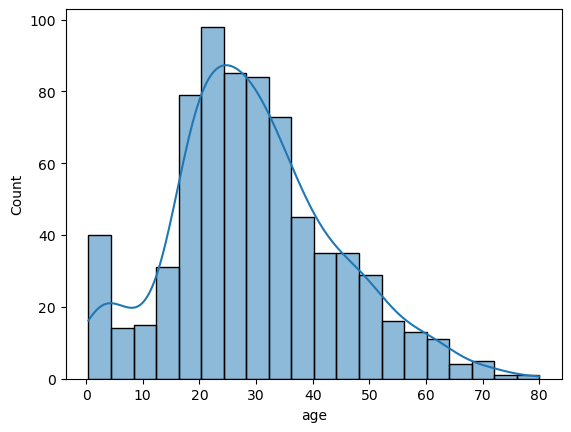

In [5]:
sns.histplot(df['age'],kde=True)

In [5]:
df['meanAge'] = df['age'].fillna(df['age'].mean())
df['meanAge'] = df['meanAge'].astype(int)

In [7]:
df[['meanAge', 'medianAge','age']]

,meanAge,medianAge,age
0,22,22.0,22.0
1,38,38.0,38.0
2,26,26.0,26.0
3,35,35.0,35.0
4,35,35.0,35.0
...,...,...,...
886,27,27.0,27.0
887,19,19.0,19.0
888,29,28.0,NaN
889,26,26.0,26.0


In [6]:
df['medianAge']=df['age'].fillna(df['age'].median())

In [8]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,meanAge,medianAge
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62,62.0


In [9]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [10]:
df['embarkedMode']=df['embarked'].fillna(df['embarked'].mode()[0]) 

In [11]:
df[['embarkedMode', 'embarked']]

,embarkedMode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [4]:
import numpy as np
import pandas as pd

In [5]:
np.random.seed(123)

nSample = 1000
class0Ratio = 0.9
n_class0=int(nSample*class0Ratio)
n_class1= nSample - n_class0

In [6]:
n_class0,n_class1

(900, 100)

In [9]:
n_class0

900

In [15]:
class0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0,scale=1,size=n_class0),
    'feature_2': np.random.normal(loc=0,scale=1,size=n_class0),
    'target':[0]*n_class0
})
class1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2,scale=1,size=n_class1),
    'feature_2': np.random.normal(loc=2,scale=1,size=n_class1),
    'target':[1]*n_class1
})

In [16]:
df = pd.concat([class0,class1]).reset_index(drop=True)

In [17]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

#### Upsampling

In [20]:
df_majority = df[df['target']==0]
df_minority = df[df['target']==1]

In [ ]:
df_minority 


,feature_1,feature_2,target
900,1.775921,0.902553,1
901,2.338840,1.058241,1
902,1.728472,3.670939,1
903,3.365531,2.067791,1
904,1.262626,3.630785,1
...,...,...,...
995,2.720690,1.978489,1
996,1.949078,3.709793,1
997,2.709784,3.324917,1
998,1.817689,1.549237,1


In [21]:
from sklearn.utils import resample

df_resample_minority = resample(df_minority,replace=True, n_samples=len(df_majority), random_state=42)

In [28]:
df_resample_minority

,feature_1,feature_2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1
...,...,...,...
952,1.188902,2.189189,1
965,3.919526,1.980541,1
976,2.810326,3.604614,1
942,3.621531,2.168229,1


In [23]:
df = pd.concat([df_resample_minority,df_majority]).reset_index(drop=True)

In [29]:
df['target'].value_counts()

target
1    900
0    900
Name: count, dtype: int64

### Down Sampling

In [18]:
np.random.seed(123)

nSample = 1000
class0Ratio = 0.9
n_class0=int(nSample*class0Ratio)
n_class1= nSample - n_class0

In [19]:
n_class1,n_class0

(100, 900)

In [20]:
class0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0,scale=1,size=n_class0),
    'feature_2': np.random.normal(loc=0,scale=1,size=n_class0),
    'target':[0]*n_class0
})
class1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2,scale=1,size=n_class1),
    'feature_2': np.random.normal(loc=2,scale=1,size=n_class1),
    'target':[1]*n_class1
})

In [21]:
df_majority1 = df[df['target']==0]
df_minority2 = df[df['target']==1]

In [22]:
df_majority1.shape

(900, 3)

In [23]:
df_minority2.shape

(100, 3)

In [25]:
from sklearn.utils import resample

df_resample_majority = resample(df_majority1,
                                replace=False, 
                                n_samples=len(df_minority2), 
                                random_state=42)

In [27]:
df_downsample = pd.concat([df_resample_majority,df_minority2])

In [29]:
df_downsample.target.value_counts()

target
0    100
1    100
Name: count, dtype: int64